# Quantitative Trading Architecture: Conditional Distillation & Markov Forecasting
This architecture utilizes deep learning as a "Present State" classifier via Annealed SGLD.
It then projects this current-state confidence forward using a 10D Markov Chain to drive trading.
Performance evaluation integrates `quantstats` metrics[cite: 4].

In [ ]:
!pip install TA-Lib mplfinance quantstats seaborn scikit-learn yfinance


In [38]:
# ==========================================
# Cell 1: Package Installation & Imports
# ==========================================
import math
import copy
import warnings
import numpy as np
import pandas as pd
import yfinance as yf
import talib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf
import quantstats as qs
import itertools

warnings.filterwarnings('ignore')
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {DEVICE}")

Using compute device: cpu


In [48]:
# ==========================================
# Cell 2: Global Control Panel
# ==========================================

# Data Parameters
TICKER = "^HSI"
START_DATE = "2011-01-01"
END_DATE = "2021-01-01"
TEST_DAYS_N = 504
ROLLING_WINDOW = 252  # 1 trading year for stable macroeconomic regime targets

# Conditional Distillation Weights
# A_WEIGHT = 0.8  # Weight given to 3D Teacher when short-term Bull is detected
# B_WEIGHT = 0.4  # Weight given to 10D Teacher during Bear/Neutral consensus

# Trading Execution Thresholds
THRESH_1_BULL_SPREAD = 0.30  # Max allowed 90% confidence spread for Long
THRESH_2_BULL_PROB   = 0.50  # Min required Bull probability for Long
THRESH_3_BEAR_SPREAD = 0.30  # Max allowed 90% confidence spread for Short
THRESH_4_BEAR_PROB   = 0.50  # Min required Bear probability for Short

TRANSACTION_FEE = 0.0005
INITIAL_WEALTH = 10000.0

# PDP Heatmap Features to Test
HEATMAP_PAIRS = [
    ('RSI', 'MA_Spread'),
    ('ADX', 'Vol_Ratio'),
    ('Fast_K', '200D_MA_Dist')
]

In [49]:
# ==========================================
# Cell 3: Data Pipeline & Backward-Looking Target Engineering
# ==========================================

class MarketDataPipeline:
    def __init__(self, ticker, start_date, end_date, time_steps=3):
        self.ticker = ticker
        self.start_date = pd.to_datetime(start_date) - pd.Timedelta(days=400)
        self.end_date = end_date
        self.time_steps = time_steps
        self.scaler = StandardScaler()
        self.feature_columns = ['RSI', 'Fast_K', 'Fast_D', 'MA_Spread', 'ADX', '200D_MA_Dist', 'Vol_Ratio']

    def fetch_data(self):
        df = yf.download(self.ticker, start=self.start_date, end=self.end_date, progress=False)
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)
        return df

    def compute_features(self, df):
        df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
        fastk, fastd = talib.STOCHF(df['High'], df['Low'], df['Close'], fastk_period=5, fastd_period=3, fastd_matype=0)
        df['Fast_K'] = fastk
        df['Fast_D'] = fastd

        sma_5 = talib.SMA(df['Close'], timeperiod=5)
        sma_20 = talib.SMA(df['Close'], timeperiod=20)
        rolling_sd = df['Close'].rolling(window=20).std().replace(0, np.nan)
        df['MA_Spread'] = (sma_5 - sma_20) / rolling_sd

        df['ADX'] = talib.ADX(df['High'], df['Low'], df['Close'], timeperiod=14)
        sma_200 = talib.SMA(df['Close'], timeperiod=200)
        df['200D_MA_Dist'] = (df['Close'] - sma_200) / sma_200

        sma_vol_20 = talib.SMA(df['Volume'], timeperiod=20).replace(0, np.nan)
        df['Vol_Ratio'] = (df['Volume'] / sma_vol_20).fillna(1.0)

        # Plotting helpers
        df['5D_MA'] = sma_5
        df['20D_MA'] = sma_20
        return df

    def generate_labels(self, df, rolling_window=ROLLING_WINDOW):
        # STRCTLY BACKWARD LOOKING: Evaluates the "Present State"
        df['Ret_3D_Back'] = df['Close'] / df['Close'].shift(3) - 1.0
        df['Ret_10D_Back'] = df['Close'] / df['Close'].shift(10) - 1.0

        # 3D Labels
        upper_3d = df['Ret_3D_Back'].rolling(window=rolling_window).quantile(0.70)
        lower_3d = df['Ret_3D_Back'].rolling(window=rolling_window).quantile(0.30)
        df['Regime_3D'] = np.select(
            [(df['Ret_3D_Back'] > upper_3d), (df['Ret_3D_Back'] < lower_3d)],
            [0, 2], default=1
        )

        # 10D Labels
        upper_10d = df['Ret_10D_Back'].rolling(window=rolling_window).quantile(0.70)
        lower_10d = df['Ret_10D_Back'].rolling(window=rolling_window).quantile(0.30)
        df['Regime_10D'] = np.select(
            [(df['Ret_10D_Back'] > upper_10d), (df['Ret_10D_Back'] < lower_10d)],
            [0, 2], default=1
        )
        return df.dropna()

    def prepare_data(self, test_days):
        raw_df = self.fetch_data()
        df = self.compute_features(raw_df)
        self.clean_df = self.generate_labels(df)

        features = self.clean_df[self.feature_columns].values
        labels_3d = self.clean_df['Regime_3D'].values
        labels_10d = self.clean_df['Regime_10D'].values

        X, Y_3D, Y_10D = [], [], []
        for i in range(len(features) - self.time_steps + 1):
            X.append(features[i:(i + self.time_steps)])
            Y_3D.append(labels_3d[i + self.time_steps - 1])
            Y_10D.append(labels_10d[i + self.time_steps - 1])

        X, Y_3D, Y_10D = np.array(X), np.array(Y_3D), np.array(Y_10D)

        split_idx = len(X) - test_days
        X_train, X_test = X[:split_idx], X[split_idx:]
        Y_train_3d, Y_test_3d = Y_3D[:split_idx], Y_3D[split_idx:]
        Y_train_10d, Y_test_10d = Y_10D[:split_idx], Y_10D[split_idx:]

        B, T, F = X_train.shape
        X_train_reshaped = X_train.reshape(-1, F)
        self.scaler.fit(X_train_reshaped)

        X_train = self.scaler.transform(X_train_reshaped).reshape(B, T, F)
        X_test = self.scaler.transform(X_test.reshape(-1, F)).reshape(X_test.shape[0], T, F)

        return X_train, X_test, Y_train_3d, Y_test_3d, Y_train_10d, Y_test_10d, self.clean_df

In [50]:
# ==========================================
# Cell 4: Neural Network Architectures & SGLD Optimizer
# ==========================================

class RegimeGRU(nn.Module):
    def __init__(self, input_size, hidden_dim, num_layers, output_size=3):
        super(RegimeGRU, self).__init__()
        self.gru = nn.GRU(input_size, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        logits = self.fc(out[:, -1, :])
        return logits

class SGLDOptimizer(torch.optim.Optimizer):
    def __init__(self, params, lr=1e-3, noise_scale=0.01, weight_decay=1e-4):
        defaults = dict(lr=lr, noise_scale=noise_scale, weight_decay=weight_decay)
        super(SGLDOptimizer, self).__init__(params, defaults)

    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None: continue
                if group['weight_decay'] != 0:
                    p.grad.data.add_(p.data, alpha=group['weight_decay'])
                lr = group['lr']
                noise = torch.randn_like(p.data) * math.sqrt(2.0 * lr) * group['noise_scale']
                p.data.add_(p.grad.data, alpha=-lr)
                p.data.add_(noise)
        return loss

def conditional_distillation_loss(student_logits, t3_logits, t10_logits, true_10d, a=0.6, b=0.3, c=0.1, temp=2.0):
    """
    Confidence-Ranked Multi-Teacher Soft-Blending Loss Function.
    - a: Weight for the hard ground-truth ('Fact') -> Highest trust
    - b: Weight for the Teacher with the highest confidence -> Intermediate trust
    - c: Weight for the Teacher with the lower confidence -> Lowest trust
    Constraint: a + b + c = 1 and a > b > c
    """
    # 1. Hard Loss (The Fact: Ground-truth cross-entropy)
    hard_loss = F.cross_entropy(student_logits, true_10d, reduction='none')

    # 2. Soft Losses (KL-Divergence for both horizons)
    soft_3d = F.kl_div(
        F.log_softmax(student_logits / temp, dim=1),
        F.softmax(t3_logits / temp, dim=1),
        reduction='none'
    ).sum(dim=1) * (temp ** 2)

    soft_10d = F.kl_div(
        F.log_softmax(student_logits / temp, dim=1),
        F.softmax(t10_logits / temp, dim=1),
        reduction='none'
    ).sum(dim=1) * (temp ** 2)

    # 3. Calculate Confidence via Max Softmax Probability for each teacher
    conf_3d = torch.max(F.softmax(t3_logits, dim=1), dim=1).values
    conf_10d = torch.max(F.softmax(t10_logits, dim=1), dim=1).values

    # 4. Dynamically rank teachers per sample based on confidence
    # If 3D confidence >= 10D confidence, 3D is Best, 10D is Second-Best. Otherwise, vice-versa.
    is_3d_better = (conf_3d >= conf_10d).float()

    best_teacher_loss = is_3d_better * soft_3d + (1 - is_3d_better) * soft_10d
    second_best_loss = is_3d_better * soft_10d + (1 - is_3d_better) * soft_3d

    # 5. Combine using hierarchical weights: a > b > c
    total_loss = (a * hard_loss) + (b * best_teacher_loss) + (c * second_best_loss)

    return total_loss.mean()

In [51]:
# ==========================================
# Cell 5: Checkpoint 1 - Teacher Training & Confusion Matrices
# ==========================================

def train_teacher(model, X_train, Y_train, epochs=150, lr=1e-3):
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        for bx, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bx.to(DEVICE)), by.to(DEVICE))
            loss.backward()
            optimizer.step()
    model.eval()

def plot_teacher_confusion_matrices(teacher_3d, teacher_10d, X_train, Y_train_3d, Y_train_10d):
    print("\n--- CHECKPOINT 1: Teacher Model Validation ---")
    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        preds_3d = torch.argmax(teacher_3d(X_tensor), dim=1).cpu().numpy()
        preds_10d = torch.argmax(teacher_10d(X_tensor), dim=1).cpu().numpy()

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(confusion_matrix(Y_train_3d, preds_3d), annot=True, fmt='d', cmap='Blues', ax=ax[0],
                xticklabels=['Bull', 'Neutral', 'Bear'], yticklabels=['Bull', 'Neutral', 'Bear'])
    ax[0].set_title("3D Teacher (Training CM)")

    sns.heatmap(confusion_matrix(Y_train_10d, preds_10d), annot=True, fmt='d', cmap='Reds', ax=ax[1],
                xticklabels=['Bull', 'Neutral', 'Bear'], yticklabels=['Bull', 'Neutral', 'Bear'])
    ax[1].set_title("10D Teacher (Training CM)")
    plt.tight_layout()
    plt.show()

In [52]:
# ==========================================
# Cell 6: Checkpoint 2 - Annealed SGLD (Conditional Distillation)
# ==========================================

def train_student_annealed(student, t3, t10, X_train, Y_train_10d, epochs=300, burn_in=150, thinning=5):
    print("\n--- CHECKPOINT 2: Training SGLD Student (Annealed Conditional Distillation) ---")
    dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(Y_train_10d, dtype=torch.long))
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Phase 1: Standard Adam to find the correct loss basin rapidly
    optimizer_adam = torch.optim.Adam(student.parameters(), lr=1e-3)
    # Phase 2: SGLD with reduced noise to explore the local basin and generate intervals
    optimizer_sgld = SGLDOptimizer(student.parameters(), lr=5e-4, noise_scale=0.005)

    mc_samples = []

    for epoch in range(epochs):
        student.train()

        # Annealing switch
        current_optimizer = optimizer_adam if epoch < burn_in else optimizer_sgld

        for bx, by in loader:
            bx, by = bx.to(DEVICE), by.to(DEVICE)
            with torch.no_grad():
                t3_logits = t3(bx)
                t10_logits = t10(bx)

            current_optimizer.zero_grad()
            student_logits = student(bx)
            loss = conditional_distillation_loss(student_logits, t3_logits, t10_logits, by)
            loss.backward()
            current_optimizer.step()

        if epoch >= burn_in and epoch % thinning == 0:
            mc_samples.append({k: v.cpu() for k, v in copy.deepcopy(student.state_dict()).items()})

    print(f"Collected {len(mc_samples)} MC Weight Samples.")

    student.eval()
    X_tensor = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    all_probs = []
    with torch.no_grad():
        for state in mc_samples:
            student.load_state_dict(state)
            all_probs.append(F.softmax(student(X_tensor), dim=1).cpu().numpy())

    mean_probs = np.mean(np.array(all_probs), axis=0)
    student_preds = np.argmax(mean_probs, axis=1)

    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(Y_train_10d, student_preds), annot=True, fmt='d', cmap='Purples',
                xticklabels=['Bull', 'Neutral', 'Bear'], yticklabels=['Bull', 'Neutral', 'Bear'])
    plt.title("Student Model (Annealed 10D/3D - Training CM)")
    plt.show()
    return mc_samples

def predict_intervals(student, mc_samples, X):
    X_tensor = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    all_probs = []
    with torch.no_grad():
        for state in mc_samples:
            student.load_state_dict(state)
            all_probs.append(F.softmax(student(X_tensor), dim=1).cpu().numpy())

    all_probs = np.array(all_probs)
    mean_probs = np.mean(all_probs, axis=0)
    # 90% confidence spread: 95th percentile - 5th percentile
    spreads = np.percentile(all_probs, 95, axis=0) - np.percentile(all_probs, 5, axis=0)
    return mean_probs, spreads

In [53]:
# ==========================================
# Cell 7: Phase II - The 10D Markov Forecasting Engine
# ==========================================

class MarkovForecaster:
    def __init__(self):
        self.transition_matrix = np.zeros((3, 3))

    def fit(self, Y_train_10d):
        for (i, j) in zip(Y_train_10d[:-1], Y_train_10d[1:]):
            self.transition_matrix[i, j] += 1
        row_sums = self.transition_matrix.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        self.transition_matrix = self.transition_matrix / row_sums

    def forecast(self, present_probs):
        return np.dot(present_probs, self.transition_matrix)

In [54]:
# ==========================================
# Cell 8: Checkpoint 3 - Trading Logic & Visual Backtest
# ==========================================

def run_backtest_and_plot(clean_df, test_days, forecasts, spreads, title, initial_wealth=INITIAL_WEALTH):
    print(f"\n--- CHECKPOINT 3: Backtest & Charting ({title}) ---")
    data = clean_df.iloc[-test_days:].copy()

    # Max spread across the 3 classes
    data['Spread'] = np.max(spreads, axis=1)
    data['Bull_Prob'] = forecasts[:, 0]
    data['Bear_Prob'] = forecasts[:, 2]

    cash = initial_wealth
    holdings = 0.0
    in_position = False

    strategy_values = []
    buy_markers = [np.nan] * len(data)
    sell_markers = [np.nan] * len(data)

    start_price = data['Close'].iloc[0]
    data['Benchmark_Value'] = data['Close'] * (initial_wealth / start_price)

    for i in range(len(data)):
        price = data['Close'].iloc[i]
        open_price = data['Open'].iloc[i]

        if i == 0:
            strategy_values.append(initial_wealth)
            continue

        prev = data.iloc[i-1]

        go_long = (prev['Spread'] < THRESH_1_BULL_SPREAD) and (prev['Bull_Prob'] > THRESH_2_BULL_PROB)
        go_short = (prev['Spread'] < THRESH_3_BEAR_SPREAD) and (prev['Bear_Prob'] > THRESH_4_BEAR_PROB)

        if go_long and not in_position:
            execution_price = open_price * (1 + TRANSACTION_FEE)
            holdings = cash / execution_price
            cash = 0.0
            in_position = True
            buy_markers[i] = data['Low'].iloc[i] * 0.96

        elif go_short and in_position:
            execution_price = open_price * (1 - TRANSACTION_FEE)
            cash = holdings * execution_price
            holdings = 0.0
            in_position = False
            sell_markers[i] = data['High'].iloc[i] * 1.04

        strategy_values.append(cash + (holdings * price))

    data['Strategy_Value'] = strategy_values

    # Advanced metrics via quantstats[cite: 4]
    strat_ret = data['Strategy_Value'].pct_change().dropna()
    bench_ret = data['Benchmark_Value'].pct_change().dropna()

    # Align indices dynamically
    strat_ret.index = pd.to_datetime(strat_ret.index)
    bench_ret.index = pd.to_datetime(bench_ret.index)

    print("\n=== QuantStats Tear Sheet ===")
    qs.reports.metrics(strat_ret, benchmark=bench_ret, prepare_returns=False)

    # Enhanced Plotting: 6 Panels
    spread_colors = ['red' if s >= THRESH_1_BULL_SPREAD else 'green' for s in data['Spread']]
    apds = [
        mpf.make_addplot(data['5D_MA'], color='blue', panel=0, width=1.0),
        mpf.make_addplot(data['20D_MA'], color='orange', panel=0, width=1.0),
        mpf.make_addplot(data['Volume'], type='bar', color='gray', panel=1, ylabel='Volume', alpha=0.5),
        mpf.make_addplot(data['RSI'], panel=2, color='purple', ylabel='RSI'),
        mpf.make_addplot([70]*len(data), color='red', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot([30]*len(data), color='green', linestyle='--', panel=2, alpha=0.4),
        mpf.make_addplot(data['Fast_K'], panel=3, color='blue', ylabel='Stoch'),
        mpf.make_addplot(data['Fast_D'], panel=3, color='orange'),
        mpf.make_addplot([80]*len(data), color='red', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot([20]*len(data), color='green', linestyle='--', panel=3, alpha=0.4),
        mpf.make_addplot(data['Spread'], type='bar', color=spread_colors, panel=4, ylabel='90% Spread'),
        mpf.make_addplot(data['Strategy_Value'], panel=5, color='darkgreen', ylabel='Equity ($)', width=1.5),
        mpf.make_addplot(data['Benchmark_Value'], panel=5, color='gray', linestyle='--', width=1.0)
    ]
    if pd.Series(buy_markers).notna().any():
        apds.append(mpf.make_addplot(buy_markers, type='scatter', markersize=120, marker='^', color='lime', panel=0))
    if pd.Series(sell_markers).notna().any():
        apds.append(mpf.make_addplot(sell_markers, type='scatter', markersize=120, marker='v', color='red', panel=0))

    mpf.plot(data, type='candle', addplot=apds, panel_ratios=(3, 1, 1, 1, 1, 1.5), figratio=(16, 14), title=f'\n{title} Execution')

In [55]:
# ==========================================
# Cell 9: Checkpoint 4 - Generalized 2D Heatmaps (PDP)
# ==========================================

def plot_all_2d_pdp_heatmaps(student_model, scaler, feature_names, X_train):
    print("\n--- GENERATING ALL 21 2D DECISION BOUNDARY HEATMAPS ---")

    # Automatically generate all unique 2-feature combinations (7 choose 2 = 21 pairs)
    feature_pairs = list(itertools.combinations(feature_names, 2))

    # Calculate training set medians to hold unselected features constant
    X_train_reshaped = X_train.reshape(-1, X_train.shape[2])
    X_train_orig = scaler.inverse_transform(X_train_reshaped)
    medians = np.median(X_train_orig, axis=0)

    student_model.eval()

    for f_x, f_y in feature_pairs:
        idx_x = feature_names.index(f_x)
        idx_y = feature_names.index(f_y)

        # Determine clean plotting bounds using the 5th and 95th percentiles to avoid outliers
        x_min, x_max = np.percentile(X_train_orig[:, idx_x], [5, 95])
        y_min, y_max = np.percentile(X_train_orig[:, idx_y], [5, 95])

        x_range = np.linspace(x_min, x_max, 40)
        y_range = np.linspace(y_min, y_max, 40)
        XX, YY = np.meshgrid(x_range, y_range)

        Z_bull = np.zeros(XX.shape)
        Z_bear = np.zeros(XX.shape)

        for i in range(XX.shape[0]):
            for j in range(XX.shape[1]):
                features = medians.copy()
                features[idx_x] = XX[i, j]
                features[idx_y] = YY[i, j]

                # Format to match sequence shape (1, time_steps, features)
                seq = np.tile(features, (3, 1))
                seq_scaled = scaler.transform(seq)
                t_input = torch.tensor(seq_scaled, dtype=torch.float32).unsqueeze(0).to(DEVICE)

                with torch.no_grad():
                    probs = F.softmax(student_model(t_input), dim=1).cpu().numpy()[0]
                    Z_bull[i, j] = probs[0]
                    Z_bear[i, j] = probs[2]

        fig, ax = plt.subplots(1, 2, figsize=(14, 5))
        c1 = ax[0].contourf(XX, YY, Z_bull, levels=20, cmap='Greens')
        ax[0].set_title('Probability of BULL Regime')
        ax[0].set_xlabel(f_x)
        ax[0].set_ylabel(f_y)
        fig.colorbar(c1, ax=ax[0])

        c2 = ax[1].contourf(XX, YY, Z_bear, levels=20, cmap='Reds')
        ax[1].set_title('Probability of BEAR Regime')
        ax[1].set_xlabel(f_x)
        ax[1].set_ylabel(f_y)
        fig.colorbar(c2, ax=ax[1])

        plt.suptitle(f"Decision Boundary Heatmaps: {f_x} vs {f_y}", fontsize=14, y=1.03)
        plt.tight_layout()
        plt.show()

Preparing Data Pipeline...

--- CHECKPOINT 1: Teacher Model Validation ---


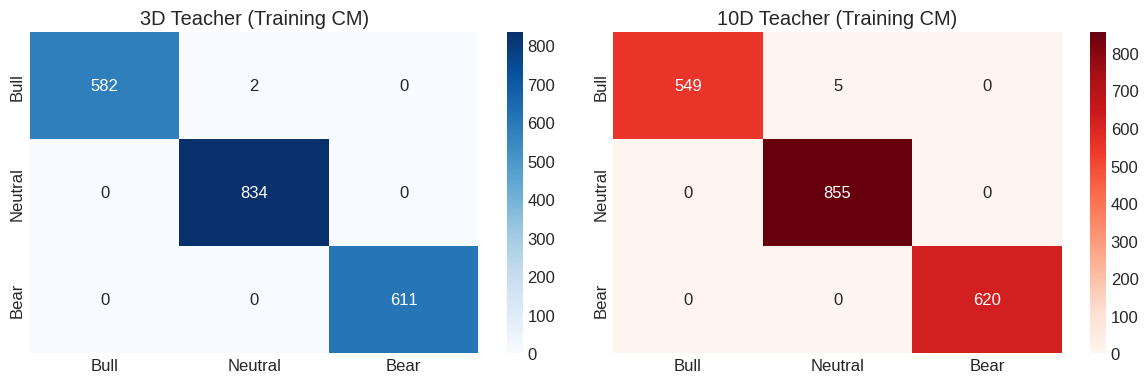


--- CHECKPOINT 2: Training SGLD Student (Annealed Conditional Distillation) ---
Collected 30 MC Weight Samples.


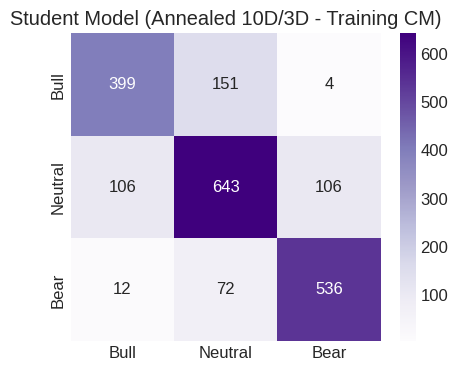


--- CHECKPOINT 3: Backtest & Charting (10D Markov Execution) ---

=== QuantStats Tear Sheet ===

Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                     Benchmark    Strategy
-------------------  -----------  ----------
Start Period         2019-01-09   2019-01-09
End Period           2020-12-31   2020-12-31
Risk-Free Rate       0.0%         0.0%
Time in Market       100.0%       58.0%

Cumulative Return    5.24%        2.96%
CAGR﹪               2.67%        1.52%

Sharpe               0.23         0.18
Prob. Sharpe Ratio   62.62%       59.86%
Sortino              0.32         0.25
Sortino/√2           0.23         0.17
Omega                1.04         1.04

Max Drawdown         -28.06%      -15.81%
Max DD Date          2020-03-23   2020-10-30
Max DD Period Start  2019-04-10   2019-07-03
Max DD Period End    2020-12-31   2020-12-31
Longest DD Days      632        

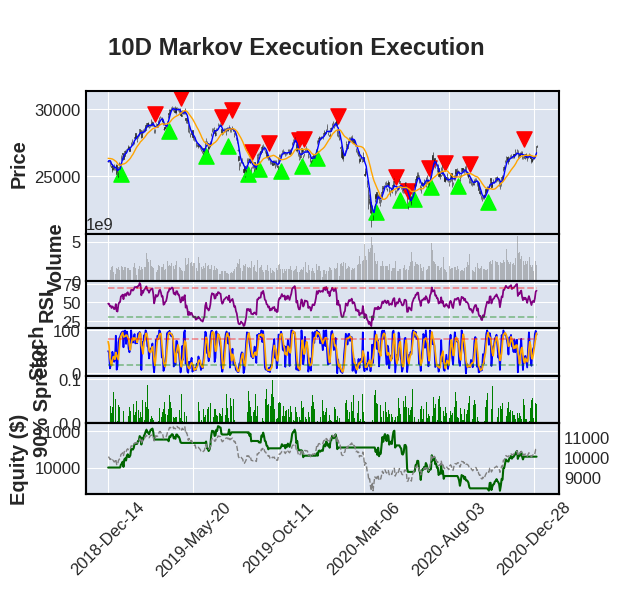


--- GENERATING ALL 21 2D DECISION BOUNDARY HEATMAPS ---


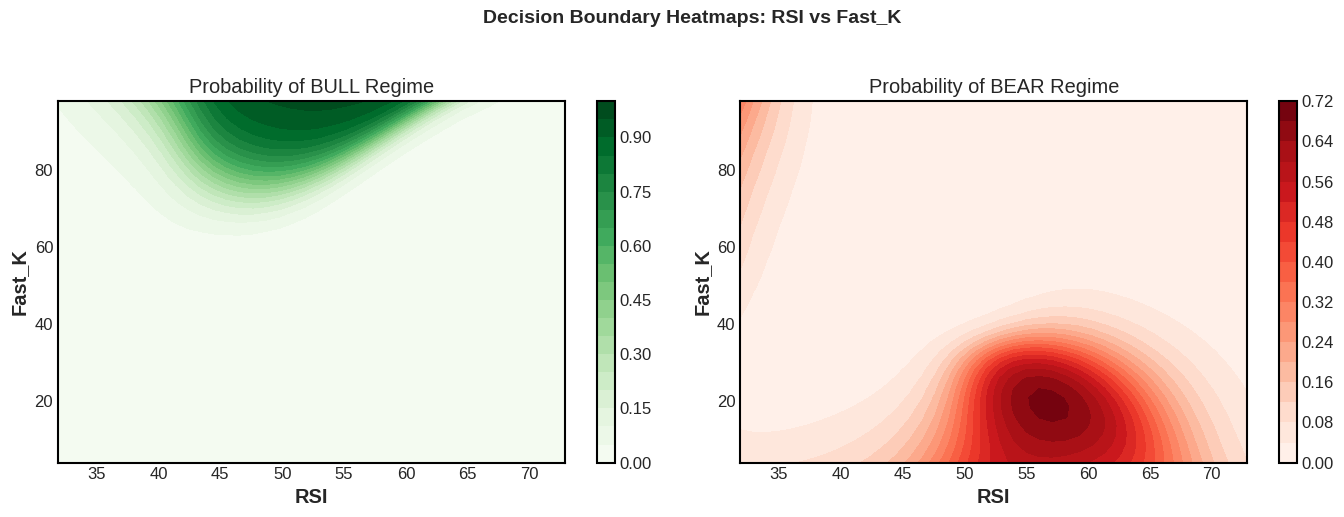

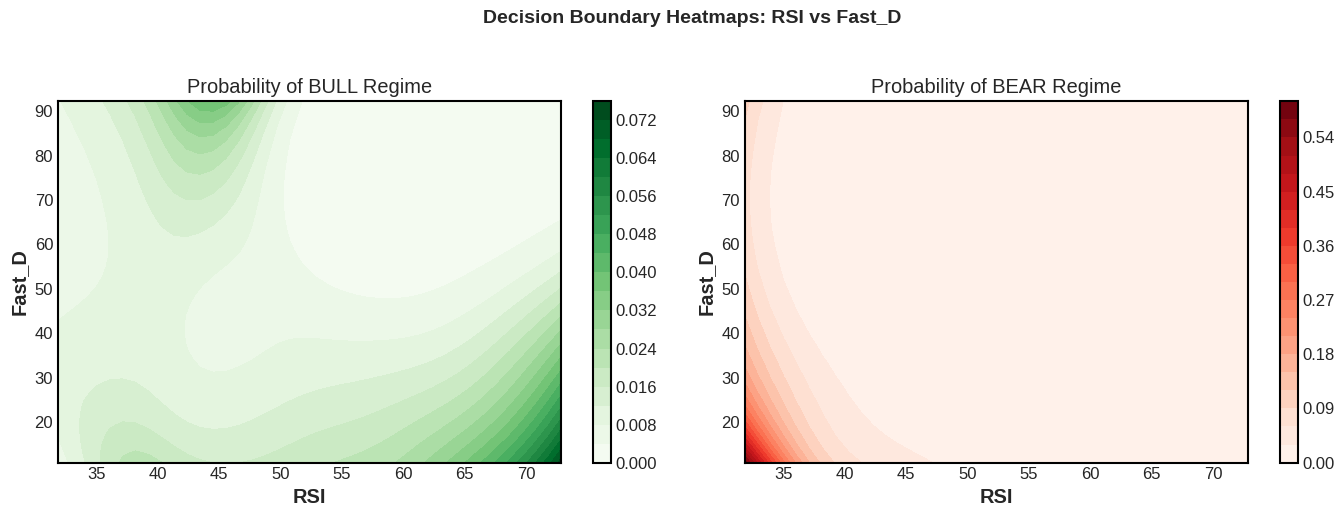

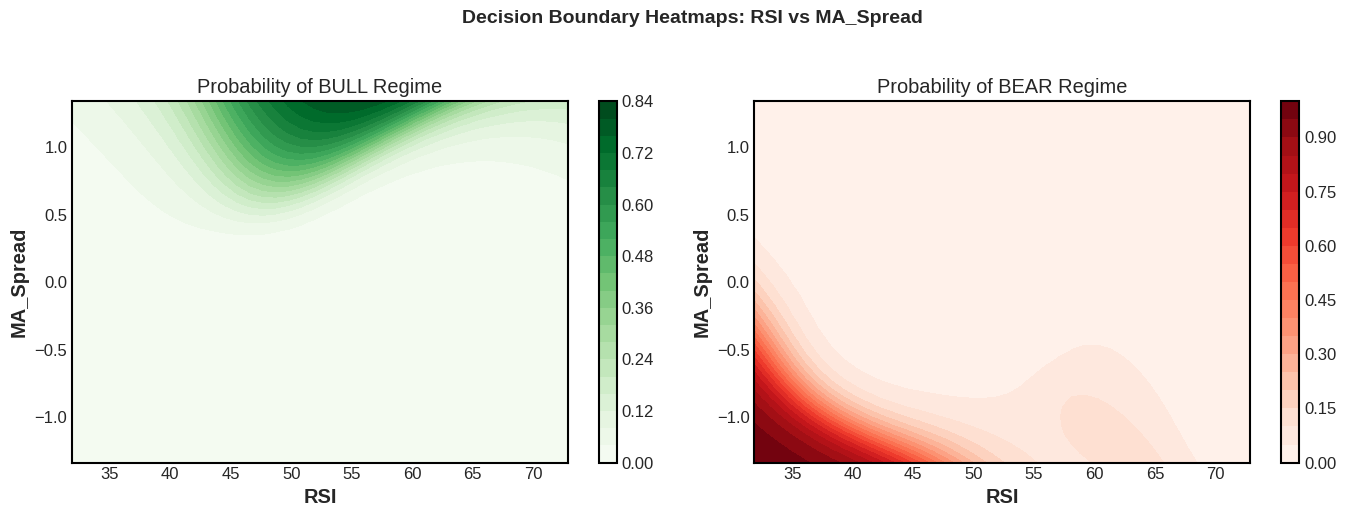

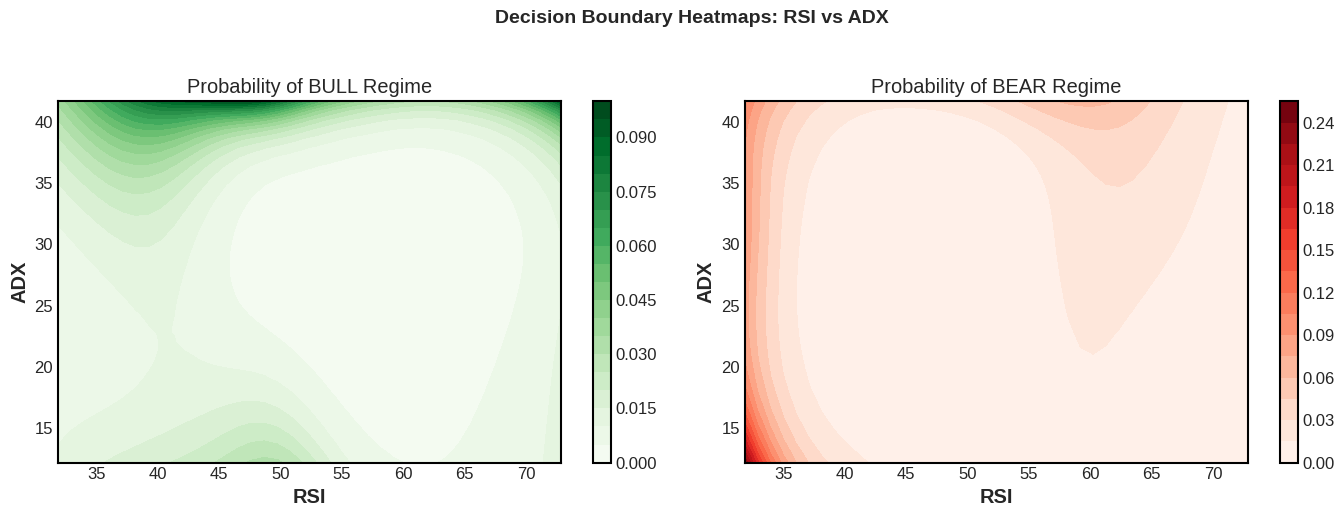

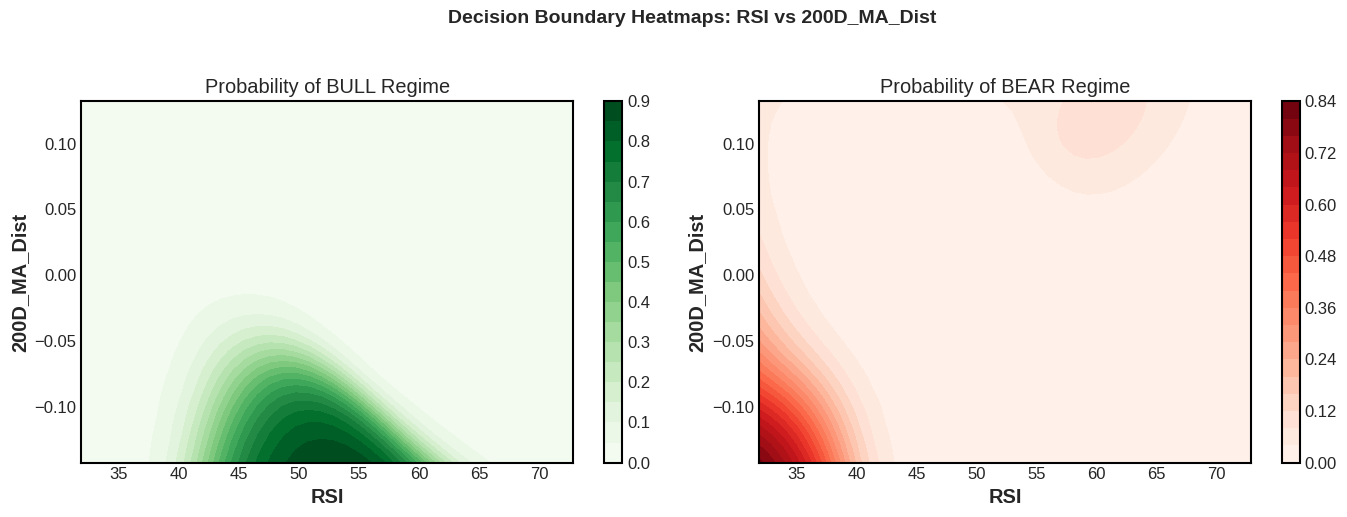

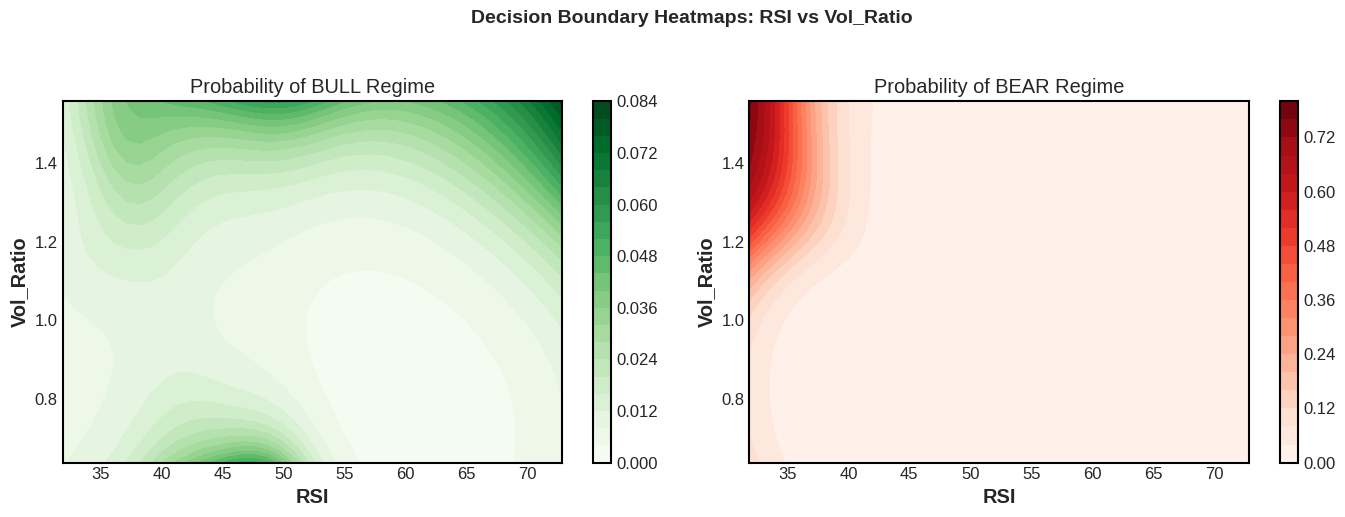

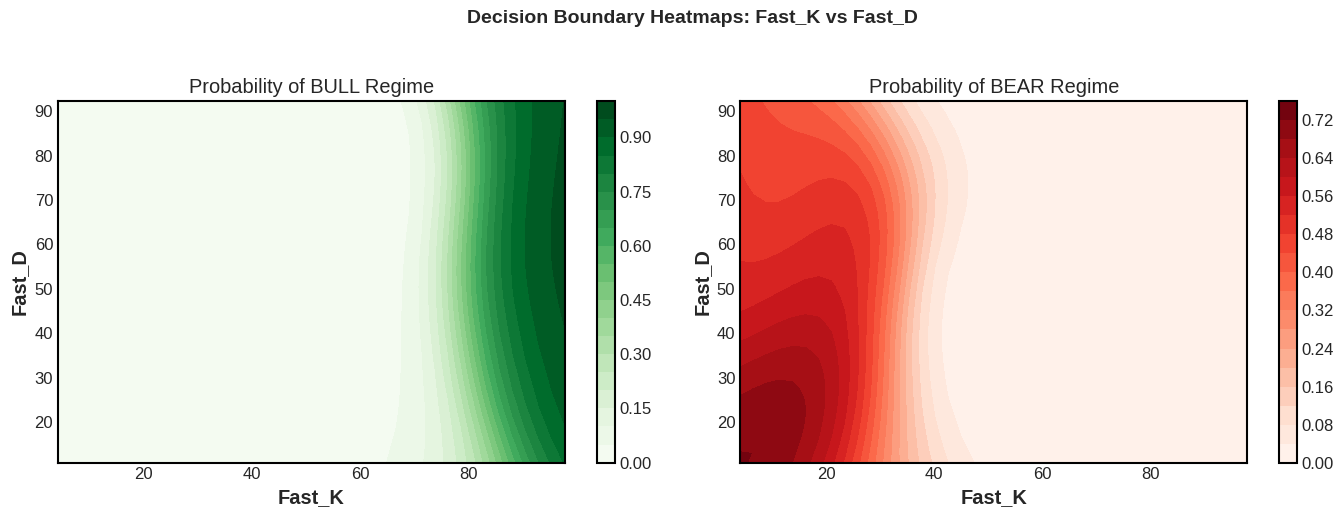

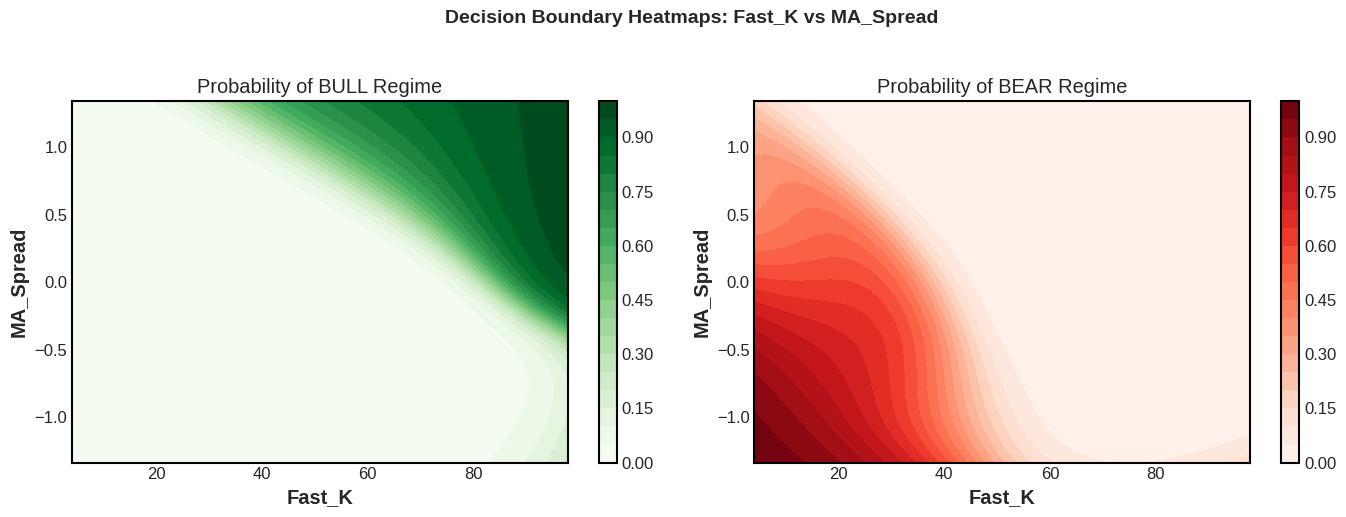

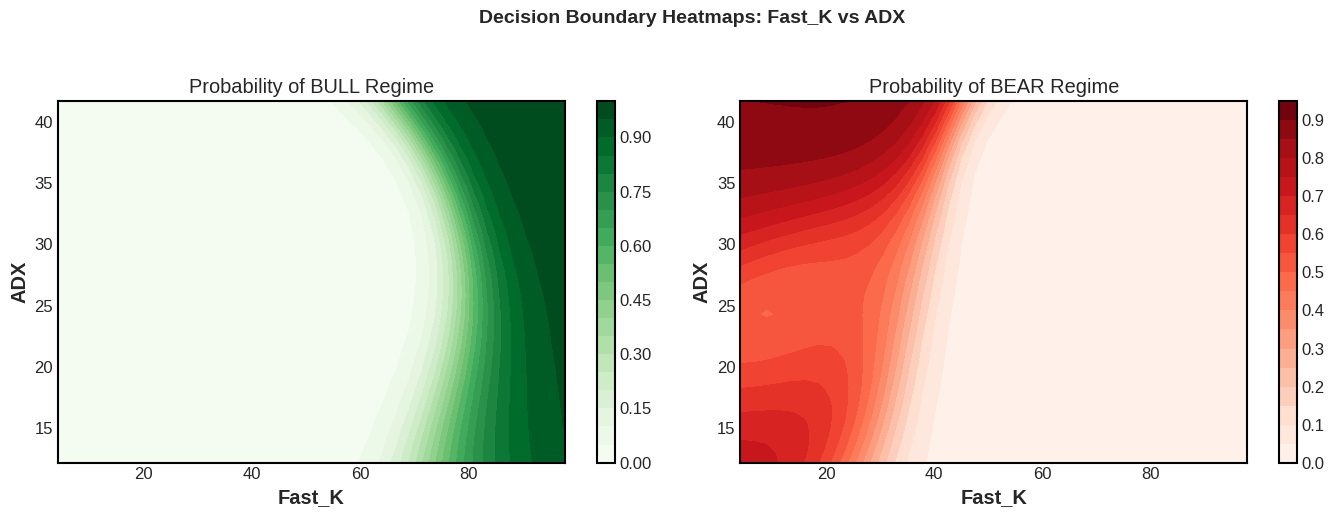

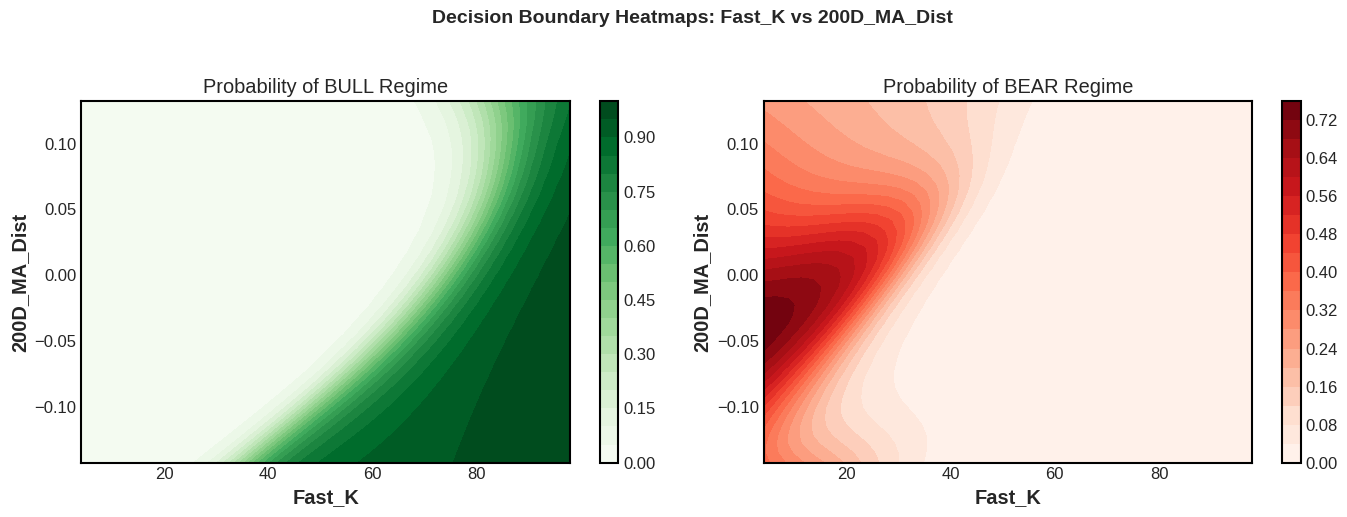

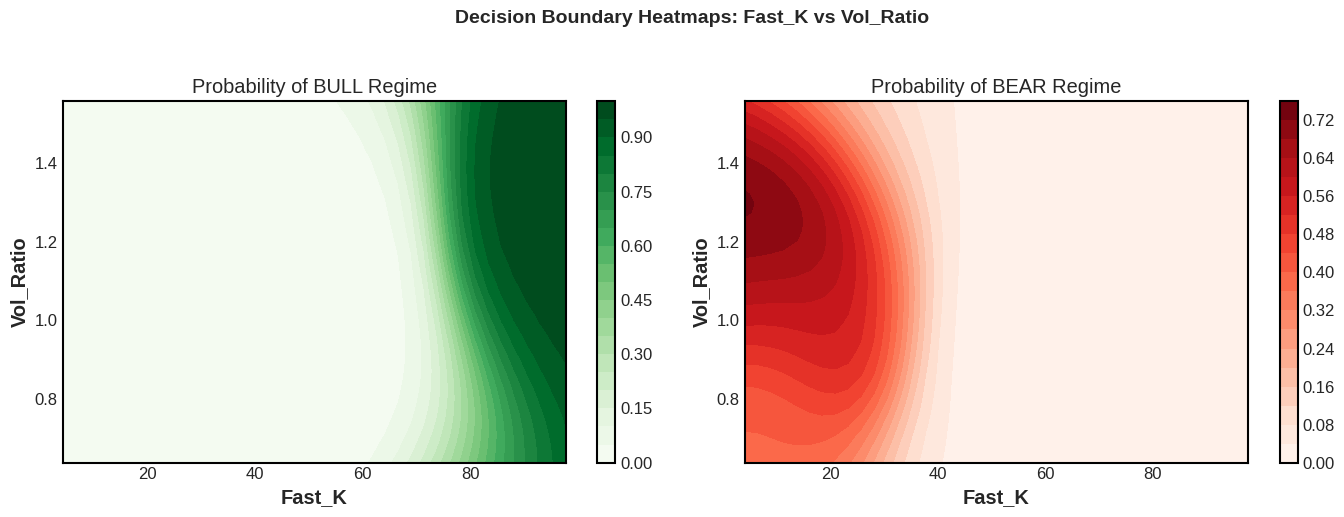

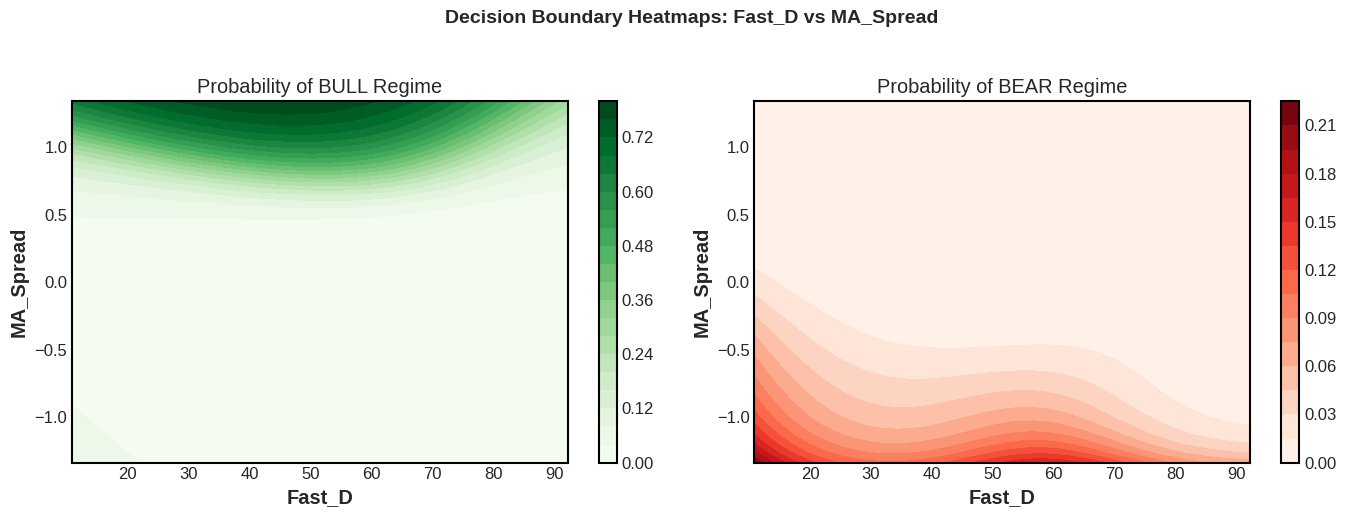

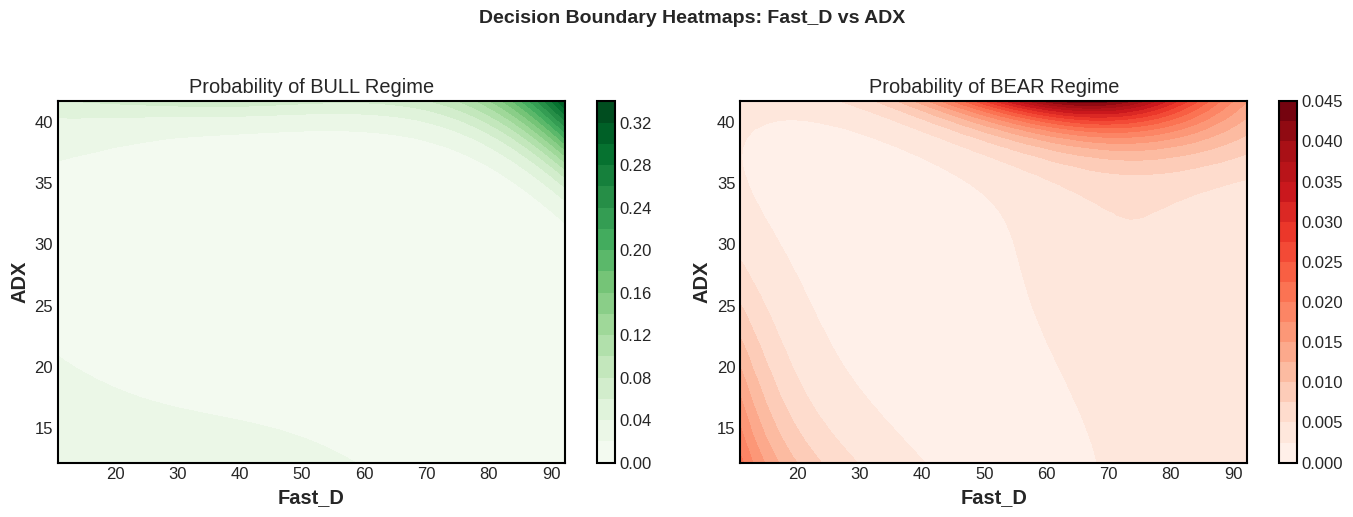

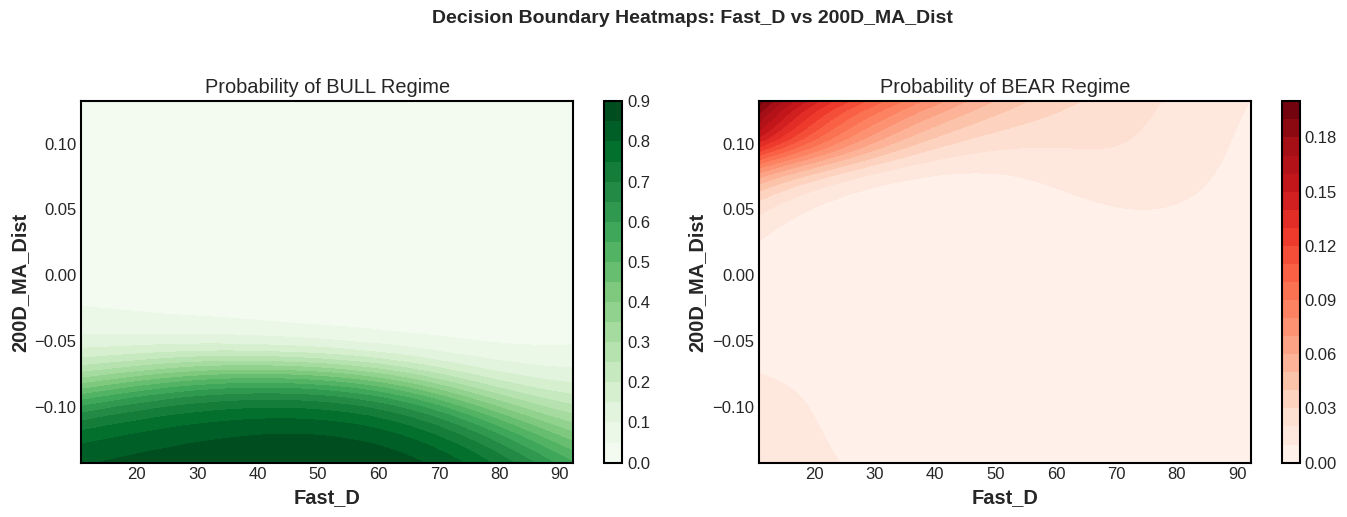

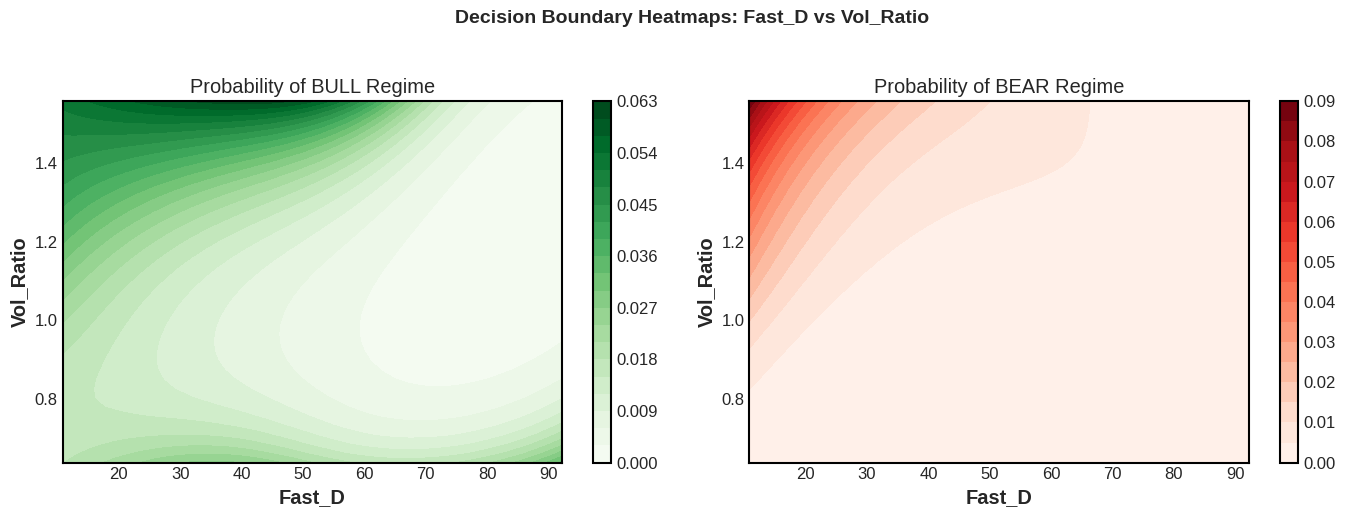

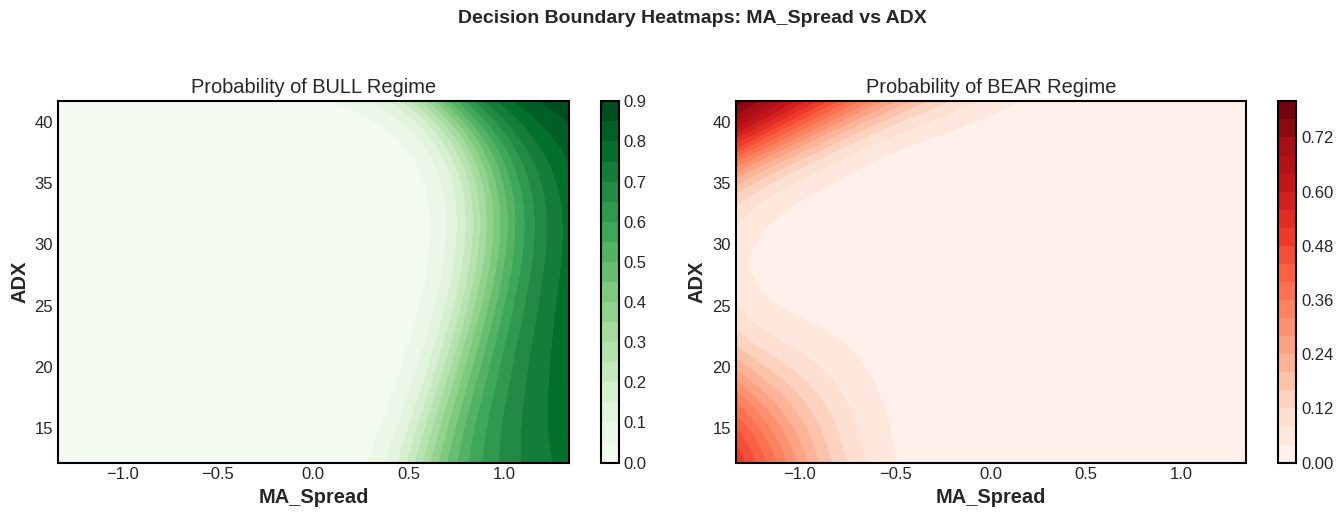

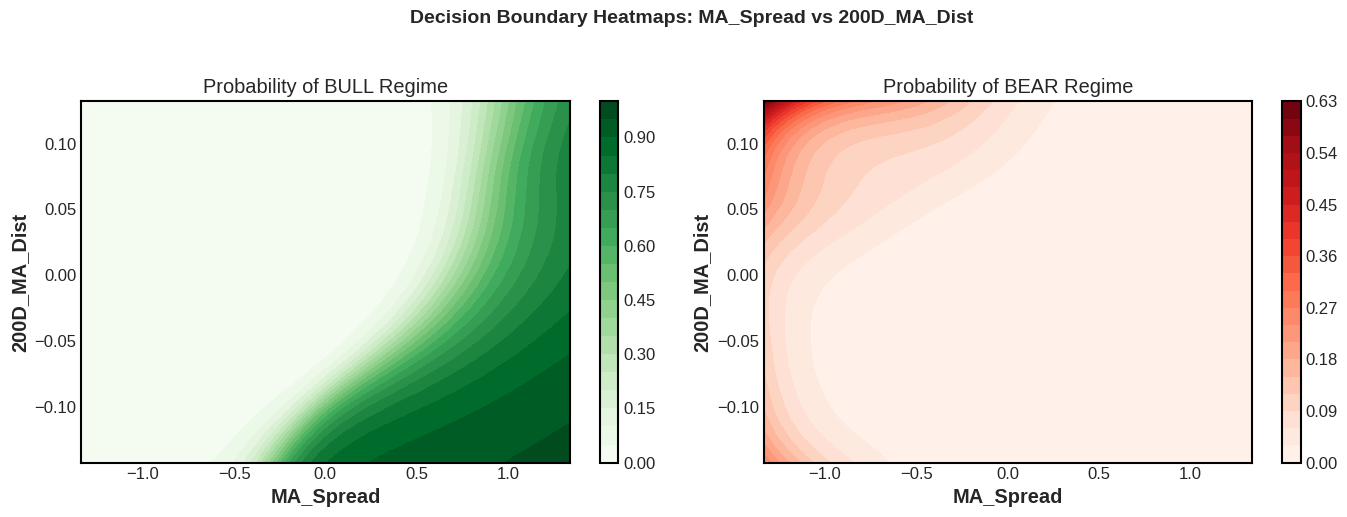

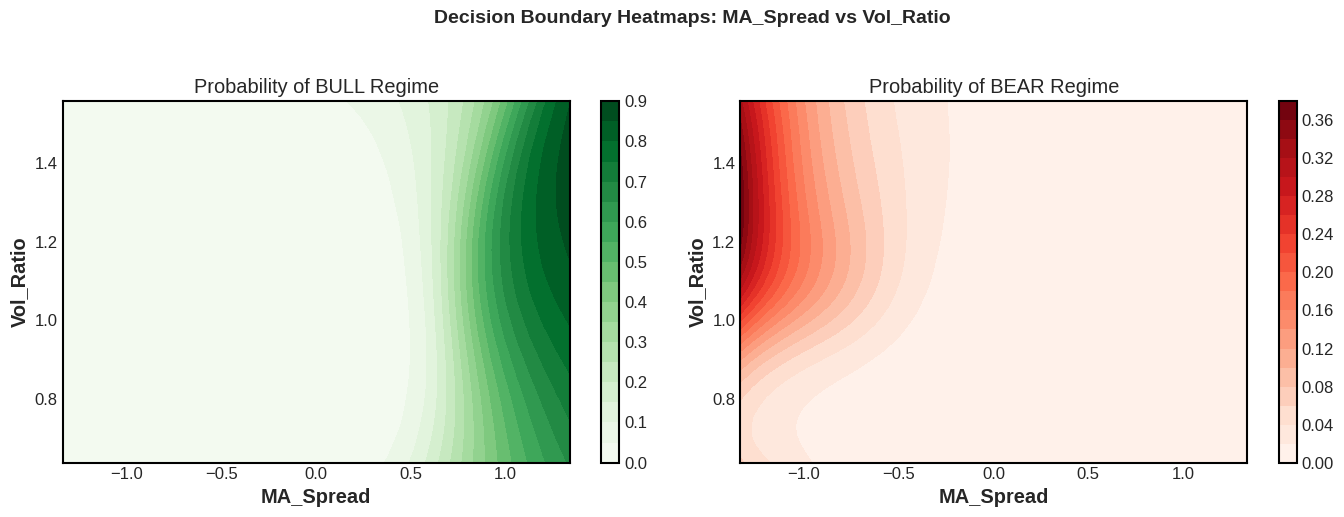

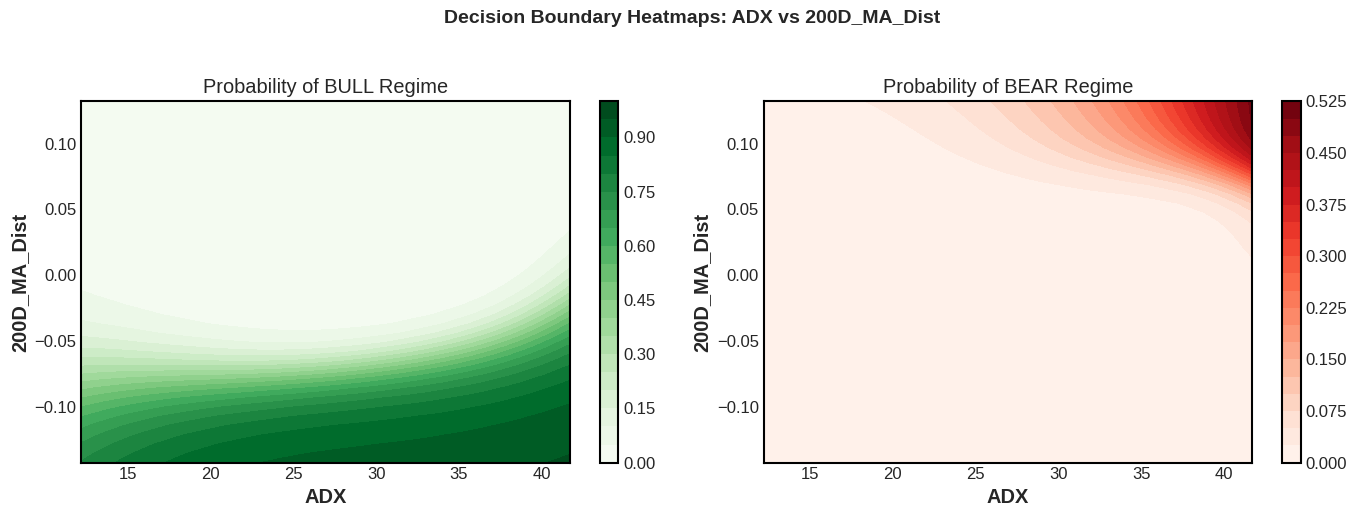

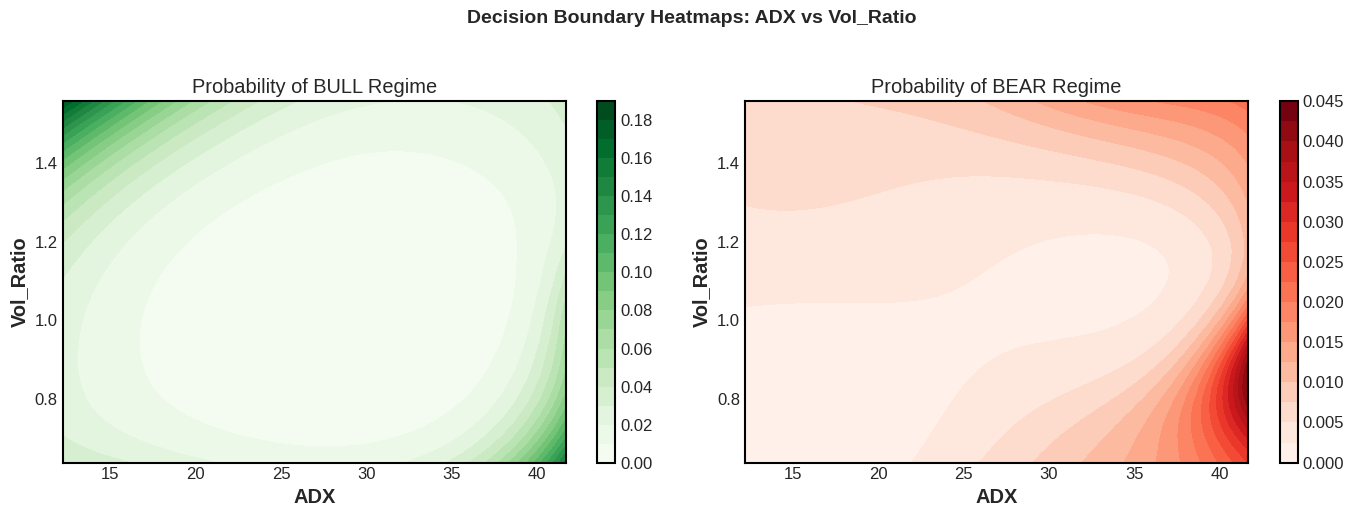

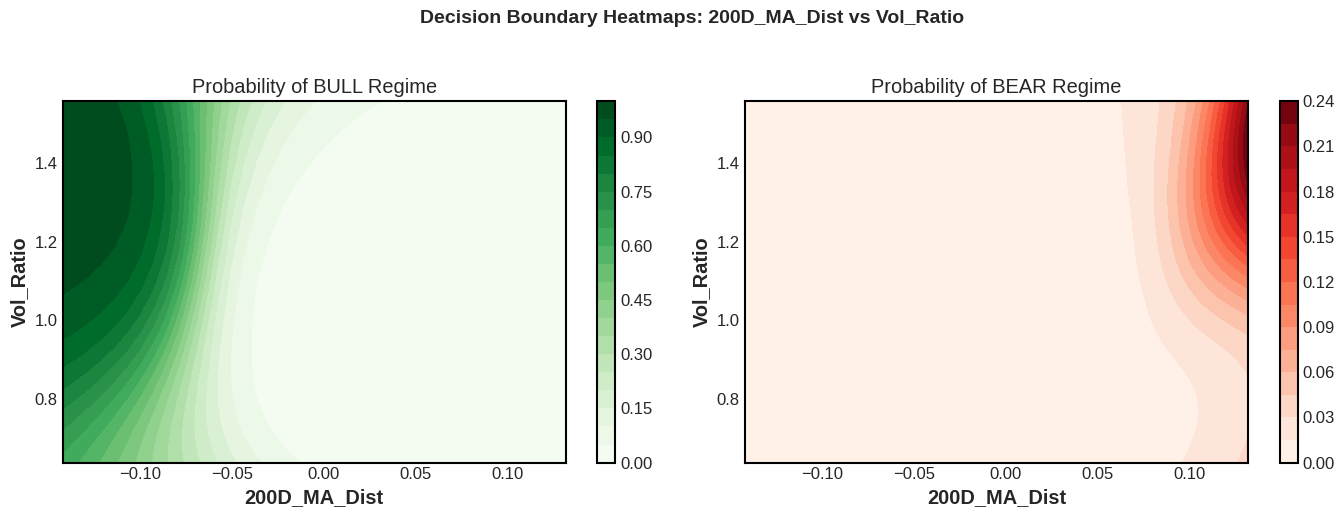

In [58]:
# ==========================================
# Cell 10: Main Execution Hook
# ==========================================

if __name__ == "__main__":
    # 1. Data Engineering
    print("Preparing Data Pipeline...")
    pipeline = MarketDataPipeline(ticker=TICKER, start_date=START_DATE, end_date=END_DATE)
    X_train, X_test, Y_train_3d, Y_test_3d, Y_train_10d, Y_test_10d, clean_df = pipeline.prepare_data(test_days=TEST_DAYS_N)
    input_size = X_train.shape[2]

    # 2. Checkpoint 1: Train Teachers
    t3 = RegimeGRU(input_size, 64, 2).to(DEVICE)
    t10 = RegimeGRU(input_size, 64, 2).to(DEVICE)
    train_teacher(t3, X_train, Y_train_3d, epochs=150)
    train_teacher(t10, X_train, Y_train_10d, epochs=150)
    plot_teacher_confusion_matrices(t3, t10, X_train, Y_train_3d, Y_train_10d)

    # 3. Checkpoint 2: Train Student via Annealed Conditional Distillation
    student = RegimeGRU(input_size, 16, 1).to(DEVICE)
    mc_samples = train_student_annealed(student, t3, t10, X_train, Y_train_10d, epochs=300, burn_in=150, thinning=5)
    mean_probs, spreads = predict_intervals(student, mc_samples, X_test)

    # 4. Phase II: Markov 10D Model (Baseline Standard)
    forecaster = MarkovForecaster()
    forecaster.fit(Y_train_10d)
    markov_forecasts = forecaster.forecast(mean_probs)

    # 5. Checkpoint 3: Backtesting & Advanced Charting
    run_backtest_and_plot(clean_df, TEST_DAYS_N, markov_forecasts, spreads, title="10D Markov Execution")

    # 6. Checkpoint 4: Automated 2D Decision Boundary Heatmaps (All 21 Pairs)
    plot_all_2d_pdp_heatmaps(student, pipeline.scaler, pipeline.feature_columns, X_train)